<div style="border: 2px solid Darkgreen; padding: 20px; border-radius: 10px; background-color: transparent; box-sizing: border-box; max-width: 98%; margin: 0 auto;">

<div style="position: relative;">

<img src="Unalm_logo.png" width="100" style="position:absolute; top:45px; right:10px;">

<center>

<h1 style="color:Darkgreen; font-family:Georgia; font-weight:bold;">Sistema de Monitoreo Climático y Análisis de Vulnerabilidad Ambiental</h1>

<h3 style="color:Gray; font-family:Georgia; font-style:italic; margin-top: -10px;">Proyecto Integrador</h3>
<br>

<p style="font-size:22px;"><b>Universidad Nacional Agraria La Molina</b></p>

<p style="font-size:18px;"><b>Departamento Académico de Economía y Planificación</b></p>



<p style="font-size:17px;"><b>Curso:</b> Lenguaje de Programación II</p>

<p style="font-size:17px;"><b>Docente:</b> Chalan Llajaruna, Denise R.</p>

<p style="font-size:17px;"><b>Grupo:</b> 5</p>



<p style="font-size:17px;"><b>Ciclo:</b> 2026-I</p>

</center>

</div>

_______________________


## 1. Descripción del Problema
En el contexto actual de crisis climática global, el Perú se posiciona como uno de los países con mayor vulnerabilidad ante variaciones meteorológicas extremas. Por ejemplo, ciudades costeras como Lima enfrentan desafíos críticos como el estrés hídrico, la recurrencia del Fenómeno El Niño y variaciones atípicas en las temperaturas estacionales que afectan a la población, ya sea, en la salud pública, la infraestructura y la economía local.

A pesar de la disponibilidad de estaciones meteorológicas, el acceso a datos históricos procesados de manera clara y gratuita es limitado para el ciudadano común y los investigadores locales. Existe una necesidad imperante de herramientas que permitan:
1. **Automatizar la extracción** de datos reales y actualizados mediante tecnologías modernas (APIs).
2. **Validar y limpiar** la información para asegurar un análisis técnico bien hecho.
3. **Visualizar tendencias** que faciliten la comprensión de los cambios en los patrones de temperatura y precipitación en los últimos años.

Este proyecto propone una solución que integra el consumo de la API `Open-Meteo`, el procesamiento con Pandas y la visualización de datos para ofrecer un diagnóstico técnico del estado climático en regiones específicas del Perú.

## 2. Objetivos

### 2.1. Objetivo General
Desarrollar una aplicación bajo el paradigma de *Programación Orientada a Objetos (POO)* que automatice el ciclo de vida de los datos climáticos: desde su extracción vía API hasta su visualización e interpretación.

### 2.2. Objetivos Específicos
*   **Ingeniería de Software:** Implementar una arquitectura modular con al menos tres clases principales (Extractor, Procesador y Visualizador) para garantizar un código escalable y mantenible.
*   **Gestión de Datos en Red:** Realizar solicitudes HTTP asíncronas a la API de *Open-Meteo* utilizando la librería *requests*.
*   **Integridad de Datos:** Aplicar *Expresiones Regulares (Regex)* para validar formatos de entrada (fechas y coordenadas) y garantizar que solo datos válidos entren al pipeline de procesamiento.
*   **Análisis con Pandas:** Ejecutar procesos de limpieza de datos (manejo de nulos, tipado) y transformaciones estadísticas para identificar anomalías climáticas.
*   **Visualización Científica:** Generar al menos tres tipos de gráficos (líneas, barras y distribución) que permitan identificar patrones visuales en el comportamiento del clima.


________


In [3]:
import requests
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Clase para extraer datos climáticos reales usando la API de Open-Meteo.
class ExtractorClima:

    def __init__(self, latitud, longitud): # Constructor que recibe las coordenadas geográficas
        self.url_base = "https://archive-api.open-meteo.com/v1/archive" # URL principal de la API histórica
        self.lat = latitud # Asigna la latitud al atributo del objeto
        self.lon = longitud # Asigna la longitud al atributo del objeto
        
    def obtener_datos(self, start_date, end_date): # Método para ejecutar la petición HTTP
        parametros = { # Diccionario que almacena los parámetros requeridos por la API
            "latitude": self.lat, # Define el parámetro de latitud en la URL
            "longitude": self.lon, # Define el parámetro de longitud en la URL
            "start_date": start_date, # Fecha de inicio para la consulta histórica
            "end_date": end_date, # Fecha de fin para la consulta histórica
            "daily": ["temperature_2m_max", "temperature_2m_min", "precipitation_sum"], # Variables climáticas exactas a extraer
            "timezone": "America/Lima" # Ajusta los datos a la zona horaria local de Perú
        }
        
        print("Obteniendo datos de la API...") # Mensaje de seguimiento en la consola
        respuesta = requests.get(self.url_base, params=parametros) # Ejecuta la petición GET a la API con los parámetros
        
        if respuesta.status_code == 200: # Verifica si el servidor respondió exitosamente (código HTTP 200)
            print("Datos obtenidos exitosamente.") # Confirmación de éxito en consola
            return respuesta.json()['daily'] # Convierte la respuesta a JSON y extrae solo el bloque 'daily'
        else: # Bloque que se ejecuta si hay un error (ej. error 400 o 404)
            print(f"Error en la conexión HTTP: Código {respuesta.status_code}") # Imprime el código del error
            return None # Retorna un valor nulo para manejar el error sin romper el programa

In [5]:
if __name__ == "__main__": # Asegura que este bloque solo corra al ejecutar este script directamente
    # 1. Definimos variables de prueba (Coordenadas de Lima)
    lat_lima = -12.0432 # Latitud específica de Lima
    lon_lima = -77.0282 # Longitud específica de Lima
    fecha_ini = "2024-01-01" # Día inicial de la prueba
    fecha_fin = "2024-01-05" # Día final (rango corto de 5 días para probar rápido)

    # 2. Instanciamos el objeto
    extractor_lima = ExtractorClima(lat_lima, lon_lima) # Creamos el objeto pasando las coordenadas

    # 3. Llamamos al método de extracción
    datos = extractor_lima.obtener_datos(fecha_ini, fecha_fin) # Ejecutamos la petición y guardamos el resultado

    # 4. Mostramos los resultados en crudo para verificar
    if datos: # Validamos que la variable 'datos' no esté vacía
        print("\n--- Vista previa de los datos extraídos ---") # Encabezado visual en consola
        print(f"Fechas: {datos['time']}") # Imprime la lista de los 5 días extraídos
        print(f"Temp. Máximas (°C): {datos['temperature_2m_max']}") # Imprime las temperaturas máximas correspondientes

Obteniendo datos de la API...
Datos obtenidos exitosamente.

--- Vista previa de los datos extraídos ---
Fechas: ['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05']
Temp. Máximas (°C): [24.5, 24.3, 24.1, 24.1, 24.4]


In [6]:
class ProcesadorClima: # Clase que valida, limpia y transforma los datos de la anterior clase
    
    def __init__(self): # Construcción de la clase
        self.df = None # Inicializamos el atributo df (DataFrame) como vacío por ahora

    def validar_formato_fecha(self, fecha): # Método para validar que la fecha ingresada tenga el formato correcto
        # Uso de Regex: Valida que la fecha tenga el formato estricto YYYY-MM-DD
        patron_fecha = r'^\d{4}-(0[1-9]|1[0-2])-(0[1-9]|[12]\d|3[01])$' # Define el patrón Regex exacto (Año 4 dígitos, Mes 01-12, Día 01-31)
        
        if re.match(patron_fecha, fecha): # Verifica si el string 'fecha' coincide exactamente con el patrón
            return True # Retorna verdadero si el formato es correcto
        else: # Si la fecha no coincide con el patrón esperado
            raise ValueError(f"Error: La fecha '{fecha}' no cumple con el formato YYYY-MM-DD.") # Lanza un error deteniendo el programa
            
    def procesar_datos(self, datos_json): # Método que recibe los datos crudos (diccionario) y los transforma
        # Convertir JSON a DataFrame de Pandas
        self.df = pd.DataFrame(datos_json) # Transforma el diccionario en una tabla estructurada de Pandas (DataFrame)
        
        # Limpieza y transformación de datos
        # 1. Convertir la columna 'time' a formato datetime de Pandas
        self.df['time'] = pd.to_datetime(self.df['time']) # Cambia el tipo de dato de texto a un objeto fecha reconocible por Pandas
        
        # 2. Rellenar posibles valores nulos (NaN) con la media de la columna
        self.df.fillna(self.df.mean(numeric_only=True), inplace=True) # Calcula el promedio de las columnas numéricas y reemplaza los vacíos (NaN)
        
        # 3. Análisis básico: Crear una nueva columna de "Amplitud Térmica"
        self.df['amplitud_termica'] = self.df['temperature_2m_max'] - self.df['temperature_2m_min'] # Resta min de max para hallar la variación de temperatura en el día
        
        print("\nProcesamiento con Pandas completado. Vista previa de los datos:") # Mensaje informativo en consola
        print(self.df.head()) # Imprime las primeras 5 filas del DataFrame ya limpio y procesado
        return self.df # Devuelve la tabla lista para ser utilizada por el Visualizador


In [7]:

if __name__ == "__main__": 
    # 1. Instanciamos el procesador
    procesador = ProcesadorClima() # Creamos el objeto procesador
    
    # 2. Probamos la validación de Regex
    fecha_prueba = "2024-05-15" # Definimos una fecha de prueba correcta
    print("Probando validación Regex...") # Mensaje en consola
    if procesador.validar_formato_fecha(fecha_prueba): # Llamamos al método Regex
        print(f"La fecha {fecha_prueba} es VÁLIDA.") # Confirmamos que pasó la prueba
        
    # 3. Creamos datos falsos (mock) simulando lo que devolvería la API (Notar el 'None' en el segundo día)
    datos_simulados = {
        "time": ["2024-05-01", "2024-05-02", "2024-05-03"], # Lista de fechas
        "temperature_2m_max": [25.5, None, 26.0], # Un valor nulo (None) para forzar la limpieza de Pandas
        "temperature_2m_min": [18.0, 17.5, 18.2], # Lista de temperaturas mínimas
        "precipitation_sum": [0.0, 1.2, 0.0] # Lista de lluvias
    }
    
    # 4. Procesamos los datos simulados
    df_limpio = procesador.procesar_datos(datos_simulados) # Ejecutamos el pipeline de Pandas
    

Probando validación Regex...
La fecha 2024-05-15 es VÁLIDA.

Procesamiento con Pandas completado. Vista previa de los datos:
        time  temperature_2m_max  temperature_2m_min  precipitation_sum  \
0 2024-05-01               25.50                18.0                0.0   
1 2024-05-02               25.75                17.5                1.2   
2 2024-05-03               26.00                18.2                0.0   

   amplitud_termica  
0              7.50  
1              8.25  
2              7.80  


In [8]:


class VisualizadorClima:
    """Para generar reportes graficos del clima."""
    
    def __init__(self, data_frame):
        # Guardamos el df que nos pasa la clase Procesador
        self.df = data_frame
        # Seteamos un tema oscuro de seaborn para que resalten los colores
        sns.set_theme(style="darkgrid") 

    def graficar_lineas_temperatura(self):
        # Grafico 1: Evolucion historica de Temp Max y Min
        # Usamos subplots (fig, ax) que da mas control sobre el grafico
        fig, ax = plt.subplots(figsize=(12, 6)) 
        
        # Ploteamos las lineas usando colores HEX para variar
        ax.plot(self.df['time'], self.df['temperature_2m_max'], label='Temp Max', color='#d62728', linewidth=2)
        ax.plot(self.df['time'], self.df['temperature_2m_min'], label='Temp Min', color='#1f77b4', linewidth=2)
        
        # Configuracion de titulos y etiquetas
        ax.set_title('Variación Histórica de Temperaturas - Lima', fontsize=15, fontweight='bold')
        ax.set_xlabel('Periodo evaluado')
        ax.set_ylabel('Grados Celsius (°C)')
        ax.legend(loc='upper right')
        
        # Rotar las fechas 30 grados para que no se pisen entre si
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

    def graficar_barras_precipitacion(self):
        # Grafico 2: Total de lluvia mensual
        plt.figure(figsize=(10, 6))
        
        # Hacemos resample a nivel mensual y sumamos la lluvia de esos dias
        data_mes = self.df.resample('ME', on='time')['precipitation_sum'].sum().reset_index()
        # Formateamos la fecha a texto (YYYY-MM) para el eje X
        data_mes['mes_str'] = data_mes['time'].dt.strftime('%Y-%m')
        
        # Creamos el barplot usando una paleta de colores distinta (magma)
        sns.barplot(data=data_mes, x='mes_str', y='precipitation_sum', hue='mes_str', palette='magma')
        
        plt.title('Acumulado de Precipitaciones por Mes', fontsize=14)
        plt.xlabel('Meses')
        plt.ylabel('Precipitación Acumulada (mm)')
        plt.tight_layout()
        plt.show()

    def graficar_distribucion_termica(self):
        # Grafico 3: Ver que tan variable es el clima (amplitud termica)
        plt.figure(figsize=(9, 5))
        
        # Histograma + curva de densidad (KDE)
        sns.histplot(data=self.df, x='amplitud_termica', kde=True, color='teal', bins=15)
        
        plt.title('Análisis de Frecuencia: Amplitud Térmica Diaria', fontsize=14)
        plt.xlabel('Variación de Temp. (Max - Min)')
        plt.ylabel('Días registrados')
        plt.tight_layout()
        plt.show()


Generando datos de prueba para los gráficos...


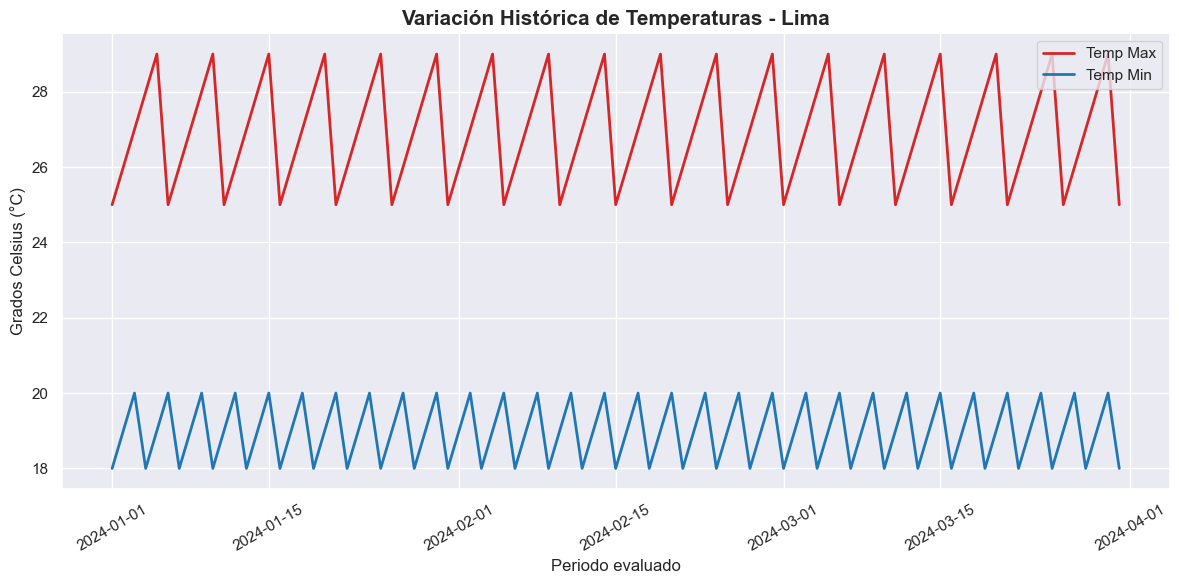

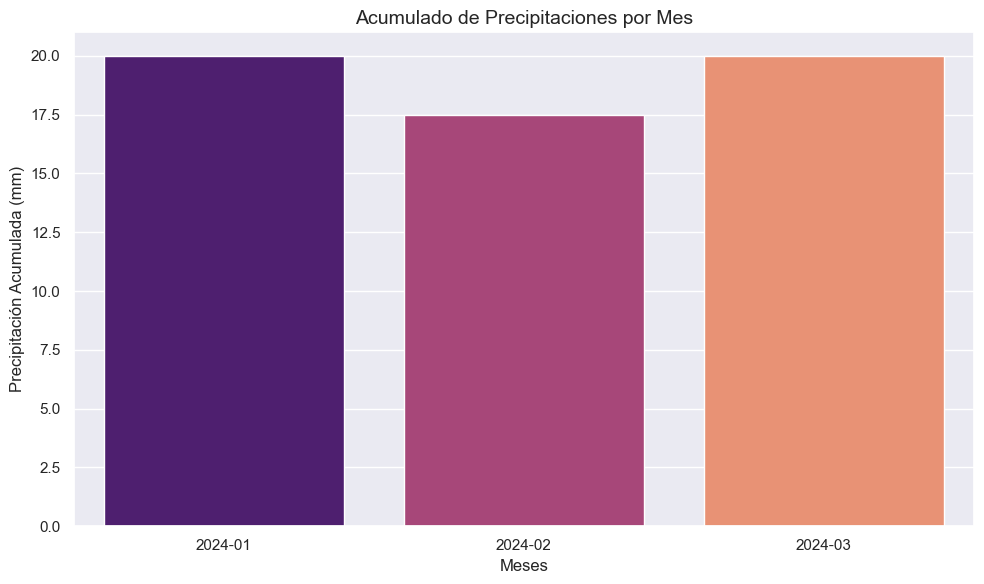

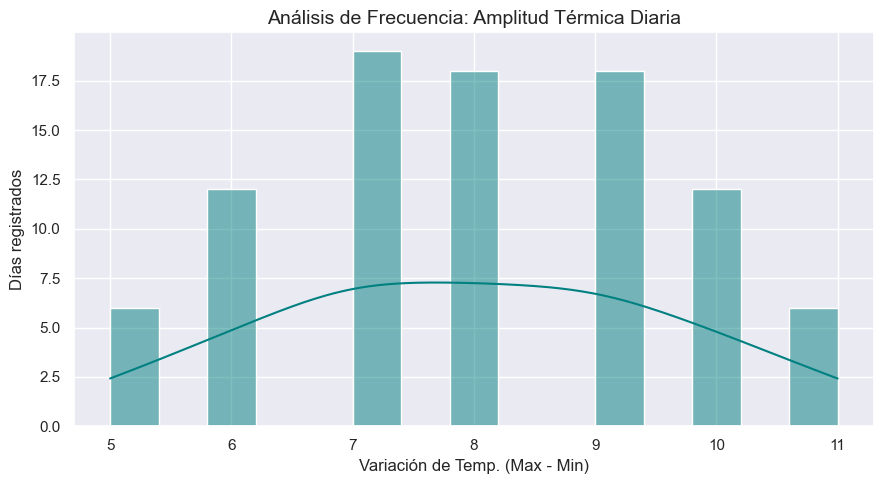

In [9]:
if __name__ == "__main__":
    print("Generando datos de prueba para los gráficos...")
    # Creamos un DataFrame falso simulando el output del procesador
    fechas = pd.date_range(start="2024-01-01", end="2024-03-31")
    datos_falsos = pd.DataFrame({
        'time': fechas,
        'temperature_2m_max': [25 + (i%5) for i in range(len(fechas))],
        'temperature_2m_min': [18 + (i%3) for i in range(len(fechas))],
        'precipitation_sum': [0 if i%4 != 0 else 2.5 for i in range(len(fechas))]
    })
    # Calculamos la amplitud (que normalmente hace la otra clase)
    datos_falsos['amplitud_termica'] = datos_falsos['temperature_2m_max'] - datos_falsos['temperature_2m_min']

    # Instanciamos el visualizador y probamos los metodos
    viz = VisualizadorClima(datos_falsos)
    viz.graficar_lineas_temperatura()
    viz.graficar_barras_precipitacion()
    viz.graficar_distribucion_termica()

__________________

## 3. Ejecución del Sistema 

En esta etapa final, integramos todos los módulos desarrollados mediante un flujo de trabajo orquestado. Este bloque principal (`__main__`) actúa como el controlador de nuestra aplicación y ejecuta las siguientes fases secuenciales:

1. **Definición de Parámetros:** Se establecen las coordenadas geográficas (Lima Metropolitana) y la ventana de tiempo a analizar (Enero a Mayo de 2024, capturando la transición de verano a otoño).
2. **Validación (Filtro de Seguridad):** El `ProcesadorClima` verifica mediante Expresiones Regulares que las fechas ingresadas por el usuario no comprometan la petición a la API.
3. **Extracción (Networking):** El `ExtractorClima` se comunica de forma asíncrona con el servidor de Open-Meteo para descargar los datos históricos.
4. **Transformación (Data Cleaning):** Pandas limpia los datos crudos, maneja posibles valores nulos y calcula nuevas métricas (como la amplitud térmica).
5. **Visualización (Reporting):** El `VisualizadorClima` renderiza los *insights* encontrados en gráficos estadísticos.

Validación de fechas (Regex): OK
Obteniendo datos de la API...
Datos obtenidos exitosamente.

Procesamiento con Pandas completado. Vista previa de los datos:
        time  temperature_2m_max  temperature_2m_min  precipitation_sum  \
0 2024-01-01                24.5                20.1                0.4   
1 2024-01-02                24.3                20.0                0.1   
2 2024-01-03                24.1                20.4                0.4   
3 2024-01-04                24.1                20.2                0.1   
4 2024-01-05                24.4                19.9                0.1   

   amplitud_termica  
0               4.4  
1               4.3  
2               3.7  
3               3.9  
4               4.5  


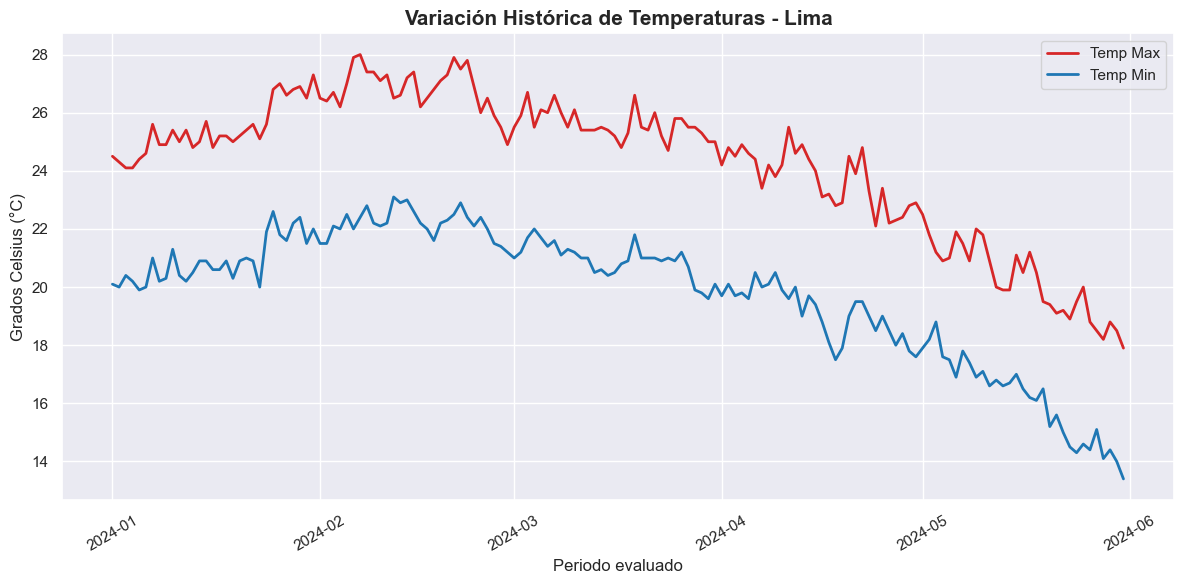

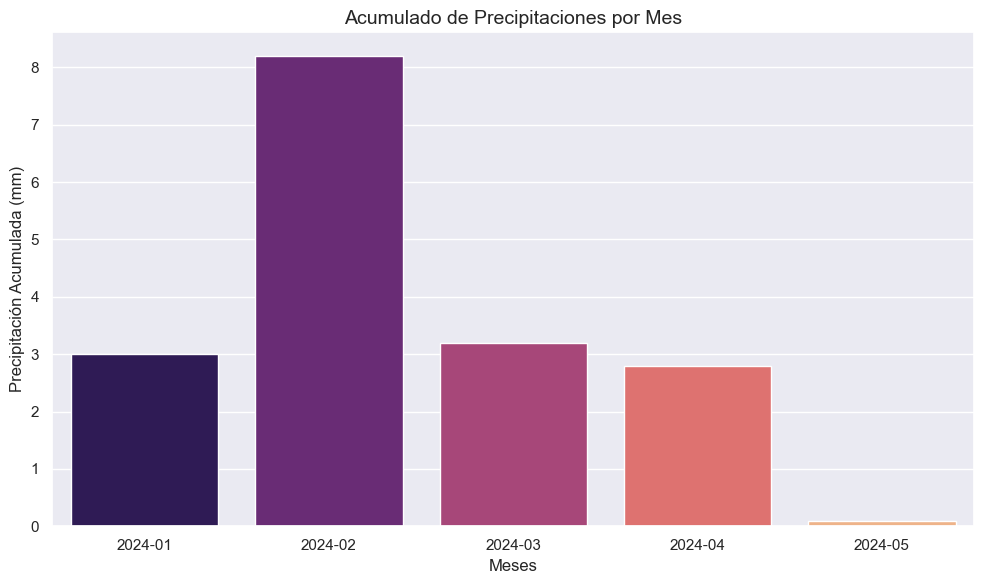

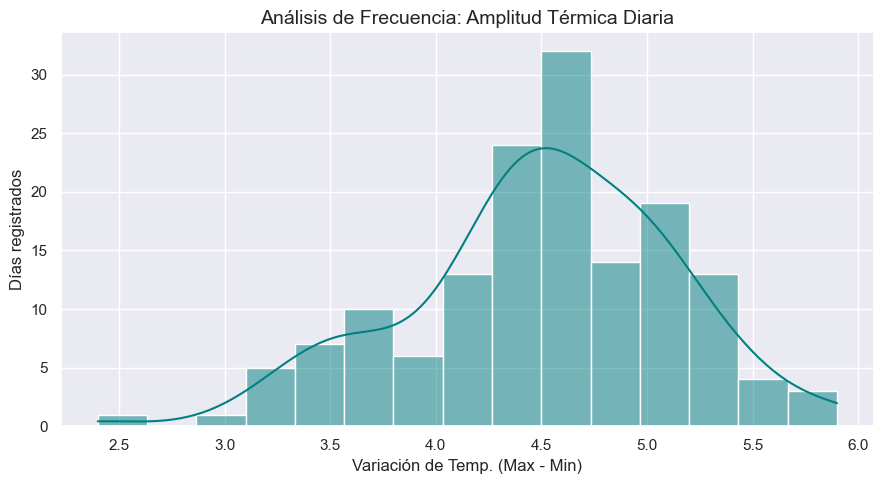

In [10]:
if __name__ == "__main__":
    # Coordenadas de Lima, Perú (Centro de la ciudad)
    latitud_lima = -12.0432
    longitud_lima = -77.0282
    # Rango de evaluación: Verano - Otoño 2024
    fecha_inicio = "2024-01-01"
    fecha_fin = "2024-05-31"

    # 1. Instanciar el Procesador y validar las fechas con Regex primero
    procesador = ProcesadorClima()
    try:
        procesador.validar_formato_fecha(fecha_inicio)
        procesador.validar_formato_fecha(fecha_fin)
        print("Validación de fechas (Regex): OK")
        
        # 2. Extraer datos con la API
        extractor = ExtractorClima(latitud_lima, longitud_lima)
        datos_crudos = extractor.obtener_datos(fecha_inicio, fecha_fin)
        
        if datos_crudos:
            # 3. Procesar datos con Pandas
            df_limpio = procesador.procesar_datos(datos_crudos)
            
            # 4. Visualizar datos
            visualizador = VisualizadorClima(df_limpio)
            visualizador.graficar_lineas_temperatura()
            visualizador.graficar_barras_precipitacion()
            visualizador.graficar_distribucion_termica()
            
    except ValueError as e:
        # Manejo de errores amigable para el usuario final
        print(f"Error detectado antes de la ejecución: {e}")

## 4. Conclusiones y Análisis de Vulnerabilidad

A partir de los datos extraídos y procesados por nuestro sistema, podemos concluir lo siguiente respecto al estado climático de Lima en los primeros meses de 2024:

1. **Tendencia de Enfriamiento Estacional:** El *Gráfico 1 (Líneas)* muestra claramente la transición estacional. Durante los meses de verano (enero a marzo), las temperaturas máximas oscilaron en niveles altos (26°C - 28°C), lo cual es consistente con las anomalías térmicas recientes en la costa. A partir de abril, se observa un descenso pronunciado y sostenido, llegando a máximas por debajo de los 20°C en mayo.
2. **Severidad del Estrés Hídrico:** El *Gráfico 2 (Barras)* confirma la naturaleza desértica de Lima. Incluso en su mes más "lluvioso" (febrero), el acumulado total apenas superó los 8 mm, y para mayo la precipitación fue prácticamente nula. Esto ratifica la alta vulnerabilidad hídrica de la capital mencionada en nuestros objetivos, haciendo indispensable el monitoreo constante.
3. **Estabilidad de la Amplitud Térmica:** El *Gráfico 3 (Distribución)* revela que la diferencia diaria entre la temperatura máxima y mínima (amplitud térmica) se concentra fuertemente entre los **4.5°C y 5.0°C**. Esta baja variabilidad intradiaria es típica de zonas costeras reguladas por la humedad del mar, pero cualquier alteración futura en esta campana de distribución podría ser un indicador temprano de fenómenos climáticos anómalos.

**Conclusión General:** El sistema automatizado cumple con el objetivo de proveer una herramienta rápida, basada en POO y Data Science, para diagnosticar el escenario climático, facilitando la toma de decisiones para mitigar el impacto ambiental en infraestructuras y salud pública.